# Model accuracy against the adjudicated gold labels

`data/adjudicated-all-rounds.csv` is the gold standard, plus the round units that never
needed adjudication because both coders already assigned the same codes. Together that is
the full 500-unit round. The whole set is scored. A unit never sees its own gold labels.

The prompt now includes decision rules and paraphrased contrastive examples distilled
from earlier misses (Death wish swallowed by Threats of violence, racial remark
swallowed by Hate speech, Consistent offensive behavior dropped next to Majority
offesnive, Calm and thoughtful replaced by No offensive content, and so on). Per-unit
context adds cue-matched gold examples for those specific codes.

Headline = micro-F1 on codes used ≥8 times. All-codes = the full codebook. Per-theme
scores are in section 4.

In [31]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

for _name in list(sys.modules):
    if _name == "thematic_ai" or _name.startswith("thematic_ai."):
        del sys.modules[_name]

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from thematic_ai import RunConfig, annotate_units, evaluate_run, frequent_codes, refine_run
from thematic_ai.pipeline import load_workspace, make_context_builder, make_system_prompt

pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 80)

EVAL_DIR = PROJECT_ROOT / "outputs" / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

## 1. Gold labels

In [32]:
ws = load_workspace(RunConfig(), test_size=0.0)
CORE = frequent_codes(ws.gold, min_support=8)

print(
    f"{len(ws.gold)} gold units scored  |  "
    f"{int(ws.gold['n_gold_codes'].sum())} gold assignments  |  "
    f"{int((ws.gold['n_gold_codes']==0).sum())} with no codes"
)
print(f"headline codes ({len(CORE)}), each used ≥8 times:")
print("  " + "; ".join(CORE))

codes_per_unit = ws.gold["n_gold_codes"].value_counts().sort_index().to_frame("units")
codes_per_unit.index.name = "codes per unit"
display(codes_per_unit)

500 gold units scored  |  809 gold assignments  |  2 with no codes
headline codes (20), each used ≥8 times:
  Hate speech and offensive language; Threats of violence; No offensive content; Consistent offensive behavior; Death wish; Majority offesnive; Normal behavior; positive content; one message is enough (offensive); One-off offensive; Harm other person; Consequences beyond suspencion; Expressed uncertainty; Not too offensive; Mix of offensive and non-offensive; Personal opinions and thoughts; insult; Permanent ban; Calm and thoughtful; Contextual understanding


,units
codes per unit,
0,2
1,269
2,163
3,56
4,7
5,1
6,1
7,1


## 2. Code every gold unit

Cached answers are reused. The calibrated run then goes through a second adjudication pass.

In [33]:
BACKEND = "openai"
MODEL = "gpt-5.1"
# The improved path is calibrated + second-pass adjudication. codebook_only and
# few_shot also receive the error-derived rules; add them here to compare.
VARIANTS = ("calibrated",)

RESULTS = {}
test_units = ws.test

for variant in VARIANTS:
    config = RunConfig(
        backend=BACKEND,
        model=MODEL,
        prompt_variant=variant,
        run_label="all_gold",
    )
    print(f"\n{config.backend}:{config.model} | {variant} | {len(test_units)} units")
    run = annotate_units(
        test_units,
        ws.codebook,
        config,
        make_system_prompt(ws, config),
        context_builder=make_context_builder(ws, config),
        progress=lambda done, total: print(f"  {done}/{total}", end="\r"),
    )
    if variant == "calibrated":
        print("\n  adjudicating...")
        run = refine_run(run, ws, progress=lambda done, total: print(f"  {done}/{total}", end="\r"))
    run.save(PROJECT_ROOT / "outputs", prefix="eval")
    full = evaluate_run(run, ws.gold_labels, ws.codebook)
    core = evaluate_run(run, ws.gold_labels, ws.codebook, codes=CORE)
    RESULTS[variant] = {"run": run, "full": full, "core": core, "config": config}
    print(
        f"\n  headline micro-F1 {core.overall['micro_f1']:.3f}  |  "
        f"all-codes micro-F1 {full.overall['micro_f1']:.3f}"
    )


openai:gpt-5.1 | codebook_only | 500 units
  500/500
  headline micro-F1 0.708  |  all-codes micro-F1 0.604

openai:gpt-5.1 | few_shot | 500 units
  500/500
  headline micro-F1 0.761  |  all-codes micro-F1 0.715

openai:gpt-5.1 | calibrated | 500 units
  500/500
  adjudicating...
  500/500
  headline micro-F1 0.754  |  all-codes micro-F1 0.722


## 3. Accuracy vs gold

Headline = the frequent codes. All codes = the full 45-code codebook.

,prompt_variant,scope,n_codes_evaluated,gold_labels,pred_labels,micro_precision,micro_recall,micro_f1,exact_set_match
0,codebook_only,headline,20,750,956,0.632,0.805,0.708,0.418
1,codebook_only,all codes,44,808,1337,0.485,0.802,0.604,0.214
2,few_shot,headline,20,750,798,0.738,0.785,0.761,0.526
3,few_shot,all codes,44,808,940,0.665,0.774,0.715,0.442
4,calibrated,headline,20,750,699,0.781,0.728,0.754,0.534
5,calibrated,all codes,44,808,776,0.737,0.708,0.722,0.472


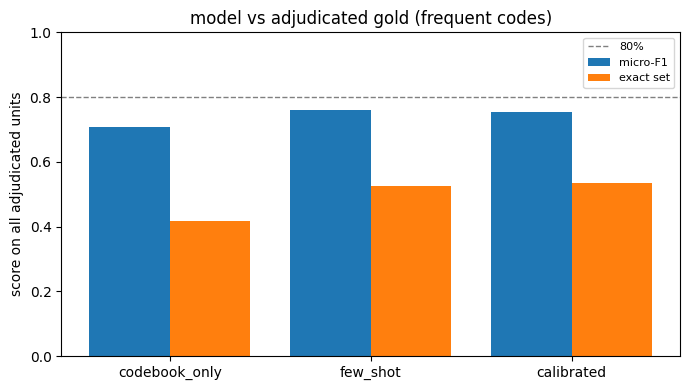

In [34]:
rows = []
for variant, entry in RESULTS.items():
    for scope, result in (("headline", entry["core"]), ("all codes", entry["full"])):
        rows.append(
            {
                "prompt_variant": variant,
                "scope": scope,
                **result.overall,
            }
        )
summary = pd.DataFrame(rows)
cols = [
    "prompt_variant", "scope", "n_codes_evaluated", "gold_labels", "pred_labels",
    "micro_precision", "micro_recall", "micro_f1", "exact_set_match",
]
display(summary[cols].round(3))
summary.to_csv(EVAL_DIR / "summary__notebook.csv", index=False)

headline = summary[summary["scope"] == "headline"]
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(headline))
ax.bar(x - 0.2, headline["micro_f1"], width=0.4, label="micro-F1")
ax.bar(x + 0.2, headline["exact_set_match"], width=0.4, label="exact set")
ax.axhline(0.80, ls="--", color="grey", lw=1, label="80%")
ax.set_xticks(x, headline["prompt_variant"])
ax.set_ylim(0, 1)
ax.set_ylabel("score on all adjudicated units")
ax.set_title("model vs adjudicated gold (frequent codes)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 4. Per-code and per-theme

In [ ]:
VARIANT = "calibrated"
result = RESULTS[VARIANT]["core"]
full = RESULTS[VARIANT]["full"]
print("frequent codes")
display(
    result.per_code[result.per_code["support_gold"] > 0]
    [["code", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)
print("all codebook codes with any gold or predicted support")
display(
    full.per_code[(full.per_code["support_gold"] > 0) | (full.per_code["support_pred"] > 0)]
    [["code", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)
full.per_code.to_csv(EVAL_DIR / f"per_code__{BACKEND}__{MODEL}__{VARIANT}.csv", index=False)

## 5. Units that differ from gold

In [35]:
errors = result.errors
print(f"{len(errors)} of {result.overall['n_units']} adjudicated units differ on the frequent codes")
display(errors[["unit_text", "gold_codes", "pred_codes", "missed", "spurious"]].head(20))

264 of 500 adjudicated units differ on the frequent codes


,unit_text,gold_codes,pred_codes,missed,spurious
0,The account should be suspended. Every comment is offensive.,Consistent offensive behavior; Extreme offensive,Consistent offensive behavior,Extreme offensive,
1,Every comment was offensive. The account should be suspended.,Consistent offensive behavior,Consistent offensive behavior; Extreme offensive,,Extreme offensive
2,The multiple death threats and attacking language aren't permitted for onlin...,Harm other person; Majority offesnive; Threats of violence,Hate speech and offensive language; Majority offesnive; Threats of violence,Harm other person,Hate speech and offensive language
3,I think they have potential to be better but they said waaay too many awful ...,Consistent offensive behavior; Majority offesnive; unjustifiable,Consistent offensive behavior; unjustifiable,Majority offesnive,
4,They never said anything offensive and seemed normal,No offensive content,No offensive content; Normal behavior,,Normal behavior
5,"They had a slip up on message 3 which could be taken as a threat, but I do n...",Appeal to intent; Ban if behavior continues; Could be joking; Expressed unce...,Appeal to intent; One-off offensive; Threats of violence,Ban if behavior continues; Could be joking; Expressed uncertainty,
6,"There was only one offensive message, and while extreme, I think suspension ...",Not too offensive; One-off offensive,Ban if behavior continues; One-off offensive,Not too offensive,Ban if behavior continues
7,"The third message contained a death threat, and was violent and offensive en...",Death wish; Threats of violence,Death wish; one message is enough (offensive),Threats of violence,one message is enough (offensive)
8,Nothing in any of the messages seemed offensive or intended to cause harm or...,No offensive content,No offensive content; Normal behavior,,Normal behavior
9,"This account used homophobic slurs, derogatory language, and racist stereoty...",Hate speech and offensive language,Consistent offensive behavior; Hate speech and offensive language; racial re...,,Consistent offensive behavior; racial remark


In [ ]:
print("per theme (any code in the theme present)")
display(
    full.per_theme[["theme", "support_gold", "support_pred", "precision", "recall", "f1"]]
    .round(3)
)
full.per_theme.to_csv(EVAL_DIR / f"per_theme__{BACKEND}__{MODEL}__{VARIANT}.csv", index=False)
full.errors.to_csv(EVAL_DIR / f"errors__{BACKEND}__{MODEL}__{VARIANT}.csv", index=False)
print(f"{len(full.errors)} of {full.overall['n_units']} units differ from gold on the full codebook")